In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
table {margin-left:0 !important; margin-right: auto;}
</style>
"""))

<font size="5" color="black">ch2. 군집 분석</font>

# 1. 군집모델(클러스터링)
- 클러스터 (cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링 (clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것

1) 중심 기반 클러스터링 [K-Means](https://commons.wikimedia.org/wiki/File:KMeans-Gaussiandata.svg)
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">

<br><br>
2) 연결기반 클러스터링 [DBSCAN](https://commons.wikimedia.org/wiki/File:DBSCAN-densitydata.svg)
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

<br><br>
3) 밀도기반 클러스터링 [DBSCAN의 변형으로 OPTICS](https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg)
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2. K-Means 클러스터링
- 연산 구조가 단순하고 처리 속도가 뛰어난 대표적 비지도 학습 알고리즘


- 최적화 메커니즘 및 수행 목적
    - 각 클러스터의 중심점(Centroid, $\mu_k$) 설정 및 데이터별 소속 클러스터 할당의 반복 수행
    - 목적함수(내부 분산 및 거리 제곱합) 값의 최소화를 통한 최적 클러스터 형성

In [4]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10,4)

In [4]:
# 분류를 위한 가상 데이터 셋 생성
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=20, # 전체 생성 데이터 개수 지정 (기본값 : 100)
    n_features=2, # 전체 독립변수(특성) 개수 지정
    n_informative=2, # 타겟 변수 예측에 유의미한 실제 정보를 가진 독립변수 개수 지정 (기본값 : 2)
    n_redundant=0, # 유용한 독립변수들의 선형 결합으로 생성된 중복 변수 수 (기본값 : 2)
    n_classes=2, # 타겟 종속변수(y)의 범주(클래스) 개수 지정 (기본값: 2)
    n_clusters_per_class=1, # 클래스 1개당 형성할 군집(클러스터) 개수 지정 (기본값: 2)
    random_state=123
)

X.shape, y.shape

((20, 2), (20,))

In [7]:
import numpy as np
value, count = np.unique(y, return_counts=True)
{v:c for v,c in zip(value, count)}

{0: 10, 1: 10}

In [8]:
np.column_stack([X, y])[:3]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

<function matplotlib.pyplot.show(close=None, block=None)>

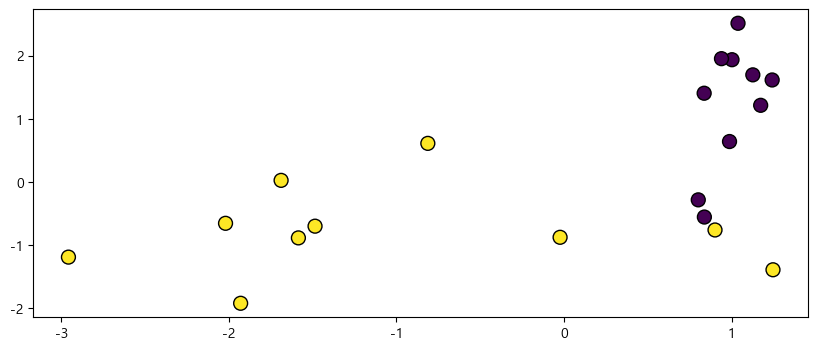

In [11]:
plt.scatter(X[:,0], X[:,1], c=y, s=100, edgecolors='k')
plt.show()

In [35]:
from sklearn.cluster import KMeans
model = KMeans(
    n_clusters=2, # 형성할 군집(클러스터) 및 생성할 중심점(Centroid) 개수 지정 (기본값: 8)
    init='k-means++', # 중심점 초기화 알고리즘 지정
    n_init='auto', # 서로 다른 초기 중심점으로 K-Means 알고리즘을 반복 실행하는 횟수
    max_iter=300, # 단일 실행당 알고리즘 수렴을 위한 최대 반복 횟수
    tol=0.0001, # 중심점 이동 거리 합에 대한 수렴 허용 오차 한계값 (도달 시 조기 종료)
    algorithm='lloyd', # K-Means 최적화 구동 알고리즘 지정 (기본 Lloyd 알고리즘 및 Elkan 알고리즘 선택 가능)
    verbose=0
)

model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [36]:
# 모델이 생성한 중심점
c0, c1 = model.cluster_centers_

In [37]:
print('실제값 :', y)
pred = model.predict(X)
print('예측값 :', pred)
labels = model.labels_
print('라  벨 :', labels)

실제값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
라  벨 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]


In [38]:
# 0 그룹으로 라벨링
X[labels==0]

array([[ 1.03859554,  2.51175389],
       [ 1.00271366,  1.93521549],
       [ 0.83653082,  1.40488232],
       [ 0.83780453, -0.554389  ],
       [ 1.12694685,  1.69570061],
       [ 0.80138648, -0.28232585],
       [ 0.9399586 ,  1.9518949 ],
       [ 1.24232232,  1.6146173 ],
       [ 0.98786201,  0.64060416],
       [ 1.17380403,  1.21379918]])

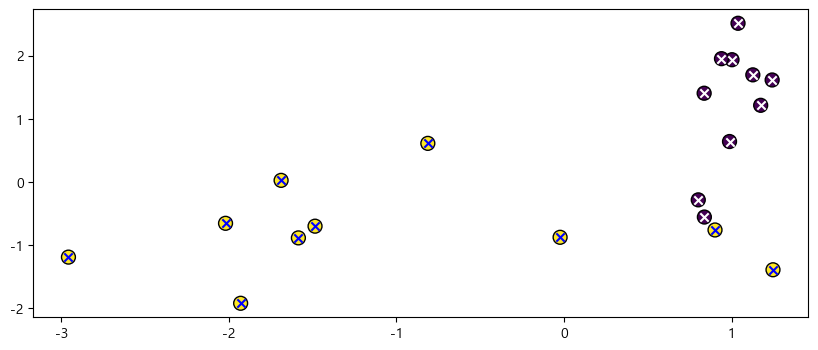

In [53]:
plt.scatter(X[:,0], X[:,1], c=y, s=100, edgecolors='k')
plt.scatter(X[labels==0, 0], X[labels==0, 1], marker='x', c='w')
plt.scatter(X[labels==1, 0], X[labels==1, 1], marker='x', c='b')


In [55]:
# X 데이터 정규화
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
pd.concat([
    pd.DataFrame(X,columns=['x0','x1']),
    pd.DataFrame(Xnor, columns=['x0_nor','x1_nor'])],
    axis=1
)

,x0,x1,x0_nor,x1_nor
0,1.038596,2.511754,0.382116,0.924114
1,1.002714,1.935215,0.460053,0.887892
2,-1.688105,0.025994,-0.999881,0.015397
3,0.901344,-0.758966,0.764937,-0.644105
4,0.836531,1.404882,0.511615,0.859215
5,-0.023176,-0.874812,-0.026484,-0.999649
6,0.837805,-0.554389,0.833951,-0.551839
7,-1.929572,-1.918940,-0.709057,-0.705151
8,-0.812496,0.611408,-0.799038,0.601281
9,1.126947,1.695701,0.553503,0.832847


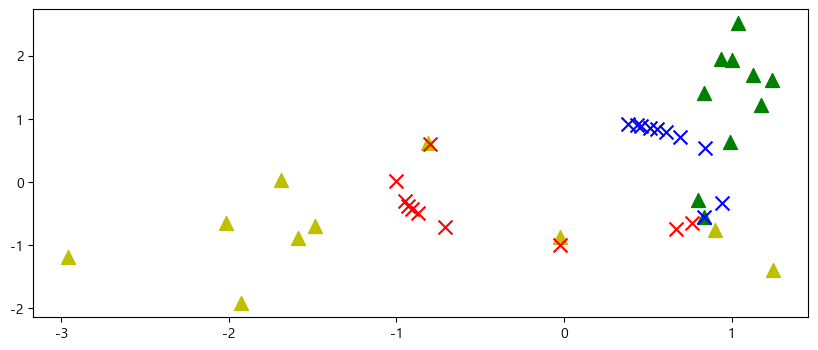

In [62]:
plt.scatter(X[y==0, 0], X[y==0, 1], s=100, marker='^', c='g')
plt.scatter(X[y==1, 0], X[y==1, 1], s=100, marker='^', c='y')

plt.scatter(Xnor[y==0, 0], Xnor[y==0, 1], s=100, marker='x', c='b')
plt.scatter(Xnor[y==1, 0], Xnor[y==1, 1], s=100, marker='x', c='r')

## ※ K-Means 클러스터링의 주요 한계점

* **군집 특성 차이에 따른 성능 저하**
    * 크기 불균형 : 군집 간 데이터 개수 또는 분포 크기 차이 발생 시 왜곡 발생
    * 밀도 불균형 : 군집 간 데이터 밀집도 차이 존재 시 최적 분할 불가
    * 비구형(Non-spherical) 구조 : 구형이 아닌 복잡한 형태(초승달형, 사슬형 등)의 군집 인식 불가


* **이상치(Outlier) 민감성**
    * 평균 기반 중심점 계산으로 인한 이상치 부근 중심점 편향 현상 발생
    
    
### K- Means 군집의 크기가 다른 경우

In [82]:
# 분류를 위한 가상 데이터 셋 생성 - group0
group0 = np.random.normal(-10, 2, (10,2))
y0 = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y0]
group0[:3]

array([[ -6.30470679, -10.6735439 ,   0.        ],
       [-10.94366425,  -7.56517368,   0.        ],
       [-11.34150967, -10.91014082,   0.        ]])

In [83]:
# 분류를 위한 가상 데이터 셋 생성 - group1
group1 = np.random.normal(10, 2, (10,2))
y1 = np.full(group1.shape[0], 1)
group1 = np.c_[group1, y1]
group1[:3]

array([[11.20622439, 11.26430106,  1.        ],
       [ 9.9944896 , 11.70978179,  1.        ],
       [13.46812888,  8.70496073,  1.        ]])

In [84]:
# 분류를 위한 가상 데이터 셋 생성 - group2
group2 = np.random.normal(0, 5, (100,2))
y2 = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y2]
group2[:3]

array([[  4.08821797,  -4.5939918 ,   2.        ],
       [  3.54836777,  -4.8573281 ,   2.        ],
       [  3.8045298 , -10.28090352,   2.        ]])

In [85]:
data = np.r_[group0, group1, group2]
data.shape

(120, 3)

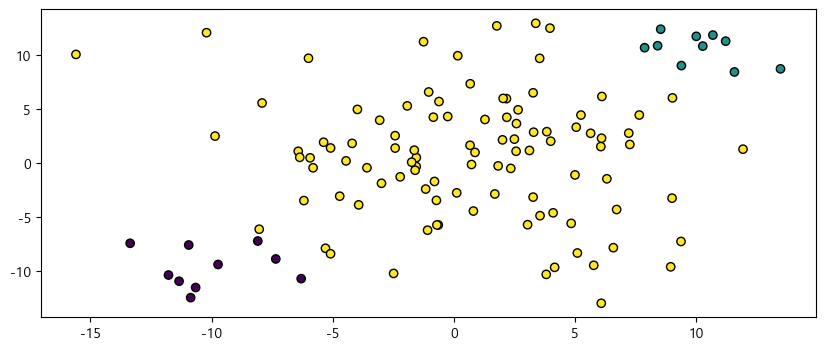

In [87]:
plt.scatter(data[:,0], data[:,1], c=data[:,2], edgecolors='k')
plt.show()

In [101]:
# 1. 3개 그룹으로 클러스터링
model = KMeans(
    n_clusters=3,
    n_init='auto'
)

model.fit(data[:,:2])

KMeans(n_clusters=3, n_init='auto')

In [102]:
centers = model.cluster_centers_

In [103]:
labels = model.labels_

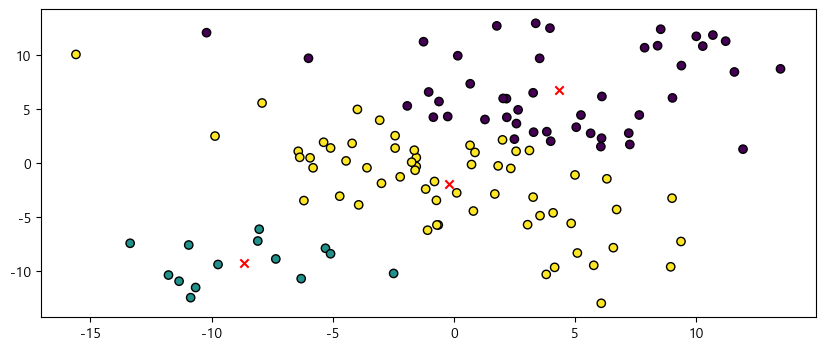

In [106]:
plt.scatter(data[:,0], data[:,1], c=labels, edgecolors='k')
plt.scatter(centers[:,0], centers[:,1], c='r', marker='x')

In [107]:
# 2. 6개 그룹으로 클러스터링
model = KMeans(
    n_clusters=6,
    n_init='auto'
)

model.fit(data[:,:2])

KMeans(n_clusters=6, n_init='auto')

In [112]:
centers = model.cluster_centers_
labels = model.labels_
labels1 = model.predict(data[:,:2])

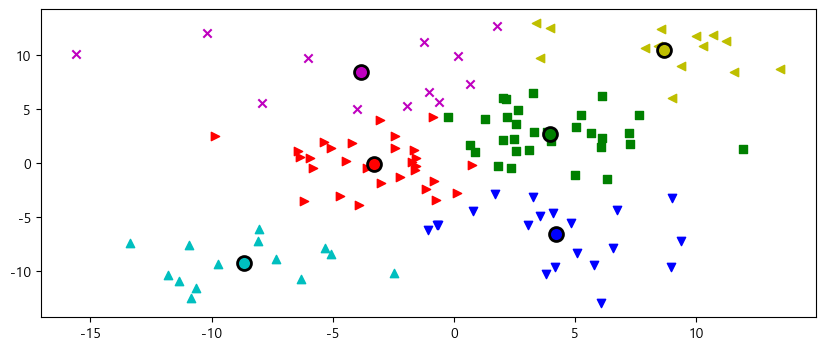

In [117]:
colors = ['r','g','b','c','m','y']
markers = ['>','s','v','^','x','<']
for i,c in enumerate(centers):
    plt.scatter(
        x = data[labels==i, 0],
        y = data[labels==i, 1],
        c = colors[i],
        marker = markers[i]
    )
    plt.scatter(c[0], c[1], s=100, c=colors[i], edgecolors='k', linewidths=2)

# 3. Hierachical 클러스터링
- 개별 데이터에서 시작해 유사한 군집끼리 단계적으로 결합하여 단일 군집을 형성하는 알고리즘


- 데이터/군집 간 거리에 기반한 계층적 구조 형성
- 사전 군집 수(K) 지정 불필요
- 군집화 결과 시각화
    - 덴드로그램(Dendrogram) 트리 구조 그래프를 통한 군집 결합 과정 및 계층 구조 시각화 지원

In [118]:
from seaborn import load_dataset
iris = load_dataset('iris')

In [120]:
# 계층적 군집화를 위한 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])

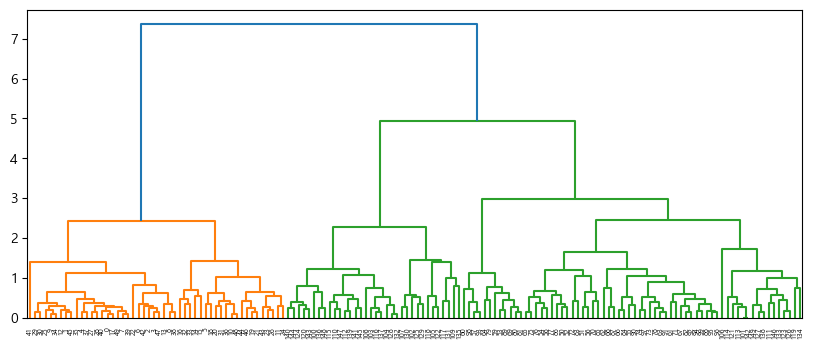

In [124]:
from scipy.cluster.hierarchy import linkage, dendrogram
# mothod : 각 클러스터 간 거리 계산 방식 설정
cluster_model = linkage(iris, method='complete')
dendrogram(cluster_model, labels=iris.index)
plt.savefig('ch2_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [125]:
# 클러스터 생성
from scipy.cluster.hierarchy import fcluster
fcluster(
    cluster_model,
    6, # 클러스터를 분할하는 기준 임계값
    criterion='distance' # 노드 간 거리를 잘라내는 기준으로 사용
)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [126]:
# 클러스터 생성 방법 1
from scipy.cluster.hierarchy import fcluster
fcluster(
    cluster_model,
    4, # 클러스터를 분할하는 기준 임계값
    criterion='distance' # 노드 간 거리를 잘라내는 기준으로 사용
)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [128]:
# 클러스터 생성 방법 2
fcluster(
    cluster_model,
    3, # 클러스터 개수
    criterion='maxclust' # 노드 간 거리를 잘라내는 기준으로 사용
)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [129]:
pred = fcluster(cluster_model, 4, criterion='distance')
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [130]:
# 자료 교정
adjusted_pred = np.choose(pred, [9, 0, 2, 1])
adjusted_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [131]:
pred_name = le.inverse_transform(adjusted_pred)
original_name = le.inverse_transform(iris['species'])
pd.crosstab(original_name, pred_name, rownames=['실제값'], colnames=['예측값'], margins=True)

예측값,setosa,versicolor,virginica,All
실제값,,,,
setosa,50,0,0,50
versicolor,0,50,0,50
virginica,0,16,34,50
All,50,66,34,150


<Axes: xlabel='petal_length', ylabel='petal_width'>

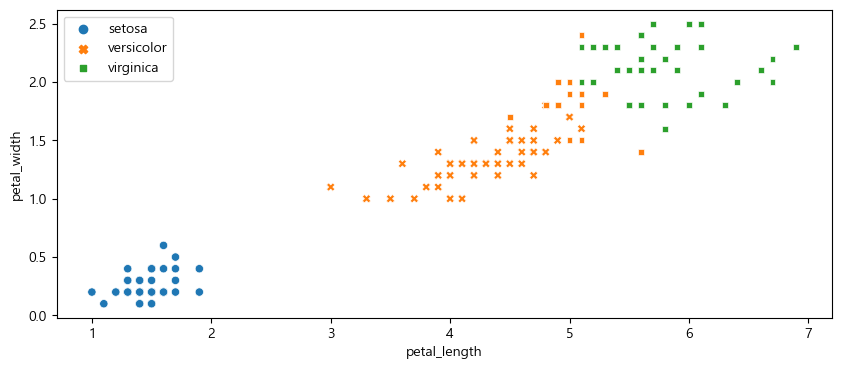

In [132]:
import seaborn as sns
sns.scatterplot(data=iris,
               x='petal_length',
               y='petal_width',
               hue=pred_name,
               style=original_name)

# 4. DBSCAN 클러스터링
* 밀도 기반 군집화 : 이웃 반경(`eps`)과 최소 포인트 수(`min_samples`)를 활용한 밀도 중심 탐색 알고리즘
* 이상치 자동 감지 : 군집 미포함 데이터를 노이즈(`-1`)로 분류하는 자동 감지 기능
* 자율적 군집 형성 : 사전 군집 개수 지정 없이 임의 형태의 비선형 군집 형성 가능
* 포인트 유형 분류 : 코어(Core), 경계(Border), 노이즈(Noise) 3가지 유형으로 데이터 구분
* 밀도 불균형 한계 : 영역별 밀도 차이가 크거나 고차원 데이터셋 활용 시 성능 저하 발생


### K- Means 군집이 비구형인 경우

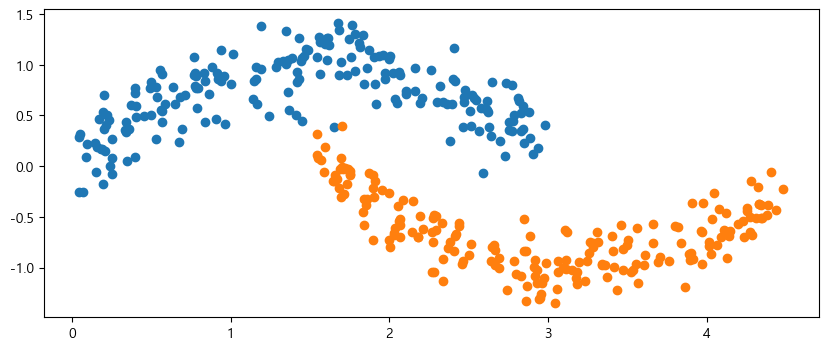

In [140]:
import numpy as np
X1 = np.random.rand(200)*3
noise = np.random.normal(0, 0.2, X1.shape)
Y1 = np.sin(X1) + noise
plt.scatter(X1, Y1)

group1 = np.c_[X1, Y1, np.full(X1.shape[0], 0)]

X2 = X1 + 1.5
noise = np.random.normal(0, 0.2, X1.shape)
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.ones(X1.shape[0])]
plt.scatter(X2, Y2)

In [141]:
data = np.r_[group1, group2]

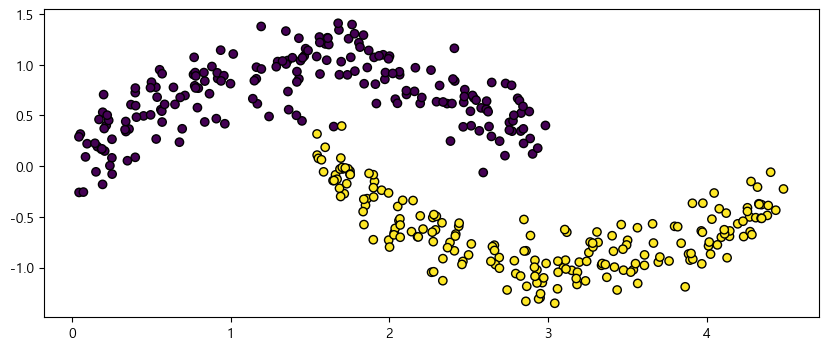

In [144]:
plt.scatter(data[:,0], data[:,1], c=data[:,2], edgecolors='k')

In [154]:
# 군집화 : 2
model = KMeans(n_clusters=2, n_init='auto')
model.fit(data[:,:2])

KMeans(n_clusters=2, n_init='auto')

In [155]:
labels = model.labels_
centers = model.cluster_centers_

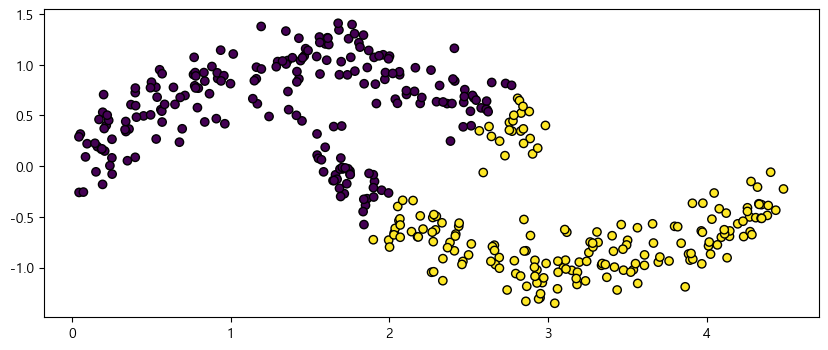

In [158]:
data[labels==1]
plt.scatter(data[:,0], data[:,1], c=labels, edgecolors='k')

In [163]:
# 군집화 : 7
model = KMeans(n_clusters=7, n_init='auto')
model.fit(data[:,:2])

KMeans(n_clusters=7, n_init='auto')

In [164]:
labels = model.labels_
centers = model.cluster_centers_

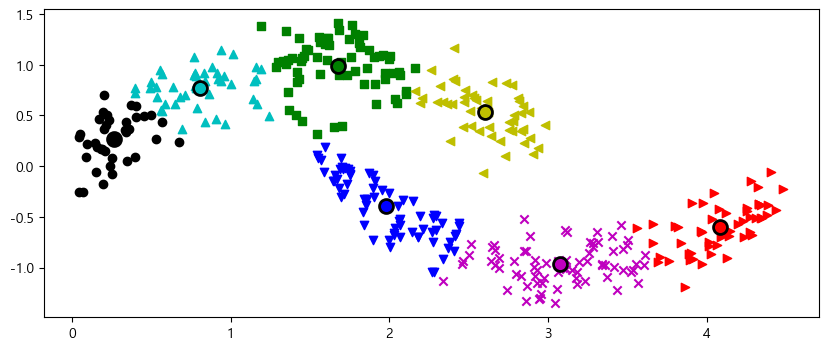

In [165]:
colors = ['r','g','b','c','m','y','k']
markers = ['>','s','v','^','x','<','o']
for i,c in enumerate(centers):
    plt.scatter(
        x = data[labels==i, 0],
        y = data[labels==i, 1],
        c = colors[i],
        marker = markers[i]
    )
    plt.scatter(c[0], c[1], s=100, c=colors[i], edgecolors='k', linewidths=2)

## DBSCAN

In [166]:
# DBSCAN
from sklearn.cluster import DBSCAN
db_model = DBSCAN(
    eps=0.3, # 반경 0.3 이내를 이웃(Neighbor) 범위로 지정
    min_samples=10 # 밀집도 확인 후 코어 포인트 확정
)
db_model.fit(data[:,:2])

DBSCAN(eps=0.3, min_samples=10)

In [176]:
labels = db_model.labels_

In [172]:
n_clusters = len(set(labels)) - ( 1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f'이상치를 제외한 label 개수: {n_clusters}, 이상치 개수 : {n_noise}')

이상치를 제외한 label 개수: 2, 이상치 개수 : 0


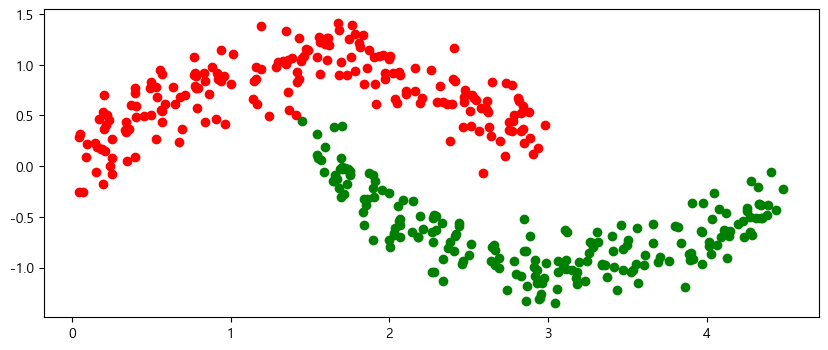

In [178]:
colors = ['r','g']
for i in range(n_clusters):
    plt.scatter(
        x = data[labels==i, 0],
        y = data[labels==i, 1],
        c = colors[i]
    )

# 5. 군집모델 성능 평가

* **예측 모형의 score 메서드**
    * K-Means score : 음수 표기 Inertia 값 (클러스터 중심과의 거리 제곱합, 0에 가까울수록 우수)
    * 기타 모델 미지원 : DBSCAN 및 계층적 군집 모델 대상 `.score()` 메서드 미제공


* **metrics 함수 (평가 지표)**
    * 실루엣 계수 (`silhouette_score`) : 응집도·분리도 통합 측정 지표 (-1 ~ 1, 1에 가까울수록 우수)
    * Calinski-Harabasz 지수 : 군집 간/군집 내 분산 비율 (높을수록 우수)
    * Davies-Bouldin 지수 : 군집 간 유사도 측정 지표 (낮을수록 우수)
    * 정답 레이블 보유 시 지표 : ARI(조정 랜드 지수), NMI(정규화 상호 정보량) 활용


* **scoring 매개변수**
    * 하이퍼파라미터 튜닝 활용 : `GridSearchCV` 및 `cross_val_score` 내 모델 자동 평가 기준 옵션
    * 커스텀 스코어러 생성 : `make_scorer()` 활용 실루엣 점수 등의 평가지표 교차검증 적용

In [179]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris_X = iris.iloc[:,:-1]
iris_y = iris.iloc[:,-1]

In [180]:
from sklearn.cluster import KMeans
iris_3cluster_model = KMeans(n_clusters=3, random_state=1, n_init=10)
iris_3cluster_model.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [184]:
pred3 = iris_3cluster_model.predict(iris_X)
pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [186]:
pred3_str = np.choose(pred3, ['versicolor','setosa','virginica'])

In [188]:
# iris_y 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_y3 = le.fit_transform(iris_y)
# pred3 자료형 순서 정렬
pred3 = np.choose(pred3, [1, 0, 2])

In [198]:
# 군집 분석의 성능 평가 함수 사용 (pred3_str, iris_y / pred3, iris_y3 필요)
pd.crosstab(iris_y3, pred3)

col_0,0,1,2
row_0,,,
0,50,0,0
1,0,48,2
2,0,14,36


In [189]:
from sklearn.cluster import KMeans
iris_2cluster_model = KMeans(n_clusters=2, random_state=1, n_init=10)
iris_2cluster_model.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [192]:
pred2 = iris_2cluster_model.predict(iris_X)
iris_y2 = np.array([0]*50 + [1]*100)

In [195]:
pred2_str = np.choose(pred2, ['setosa','vir'])
iris_y2_str = np.choose(iris_y2, ['setosa','vir'])

In [197]:
# 군집 분석의 성능 평가 함수 사용 (pred2_str, iris_y2_str / pred2, iris_y2 필요)
pd.crosstab(iris_y2_str, pred2_str)

col_0,setosa,vir
row_0,,
setosa,50,0
vir,3,97


## 5.1 조정 랜드 지수 (Adjusted Rand Index, ARI)
- 군집화 결과와 실제 정답 레이블 간의 유사도를 측정하는 비지도학습 평가 지표

In [199]:
from sklearn.metrics import adjusted_rand_score

In [200]:
# 성능 평가 : 클러스터 3개
adjusted_rand_score(labels_true=iris_y, labels_pred=pred3_str)

0.7302382722834697

In [201]:
# 성능 평가 : 클러스터 2개
adjusted_rand_score(labels_true=iris_y2, labels_pred=pred2)

0.920405050901892

## 5.2 상호 정보량 (Mutual Information, MI)
- 두 확률 변수(실제 정답 레이블과 군집화 예측 결과) 간의 공유되는 정보량을 측정하는 평가지표

In [202]:
from sklearn.metrics import mutual_info_score

In [203]:
# 성능 평가 : 클러스터 3개 ; 클러스터 개수가 높으면 점수가 높아지는 경향
mutual_info_score(iris_y, pred3_str)

0.8255910976103356

In [204]:
# 성능 평가 : 클러스터 2개
mutual_info_score(iris_y2, pred2)

0.5596576064224734

In [205]:
from sklearn.metrics import normalized_mutual_info_score

In [206]:
# 성능 평가 : 클러스터 3개
normalized_mutual_info_score(iris_y, pred3_str)

0.7581756800057784

In [207]:
# 성능 평가 : 클러스터 2개
normalized_mutual_info_score(iris_y2, pred2)

0.8703851565631638

## 5.3 기타 성능 평가 함수

In [208]:
from sklearn.metrics import homogeneity_score

In [209]:
# 성능 평가 : 클러스터 3개
homogeneity_score(iris_y, pred3_str)

0.7514854021988338

In [210]:
# 성능 평가 : 클러스터 2개
homogeneity_score(iris_y2, pred2)

0.8792539652679946

In [211]:
from sklearn.metrics import completeness_score

In [212]:
# 성능 평가 : 클러스터 3개
completeness_score(iris_y, pred3_str)

0.7649861514489815

In [213]:
# 성능 평가 : 클러스터 2개
completeness_score(iris_y2, pred2)

0.861693475999054

In [214]:
from sklearn.metrics import v_measure_score

In [215]:
# 성능 평가 : 클러스터 3개
v_measure_score(iris_y, pred3_str)

0.7581756800057784

In [216]:
# 성능 평가 : 클러스터 2개
v_measure_score(iris_y2, pred2)

0.870385156563164

## 5.4 실루엣 계수 (Silhouette Score)
- 데이터 간의 거리에 기반하여 군집화 품질을 평가하는 비지도학습 대표 평가지표
- ARI나 NMI 같은 지표와 달리, 실제 정답 레이블이 없어도 데이터 자체의 거리(응집도와 분리도)만으로 계산 가능

In [2]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0 ≤ x < 1 범위의 균등 분포 난수 n개 발생
noise = np.random.normal(0, 0.2, X1.shape)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.zeros(X1.shape[0])]

X2 = X1 + 1.5
noise = np.random.normal(0, 0.2, X1.shape)
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.ones(X2.shape[0])]

data = np.r_[group1, group2]
data[::100]

array([[ 0.65433255,  0.20833909,  0.        ],
       [ 1.34674587,  0.91185913,  0.        ],
       [ 2.15433255, -0.61203559,  1.        ],
       [ 2.84674587, -1.13639457,  1.        ]])

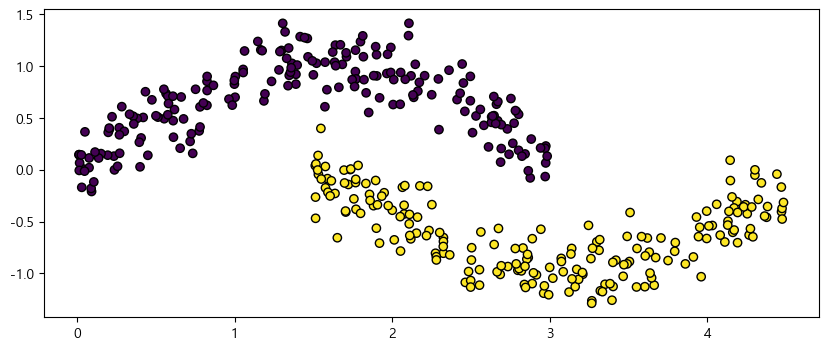

In [5]:
import matplotlib.pyplot as plt
plt.scatter(
    x=data[:,0],
    y=data[:,1],
    c=data[:,2],
    edgecolors='k'
)

In [22]:
# 실루엣 계수
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# KMeans; cluster_labels의 성능 평가 지표 확인 : 클러스터 수 - 6일 때, 가장 높은 실루엣 계수를 가지
range_n_clusters = [2,3,4,5,6,7,8,9,10]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=3)
    model.fit(data[:,:-1])
    cluster_labels = model.labels_
    score = silhouette_score(
        data[:,:-1], # 학습 데이터
        cluster_labels # 예측 결과 데이터
    )
    print(f'클러스터 : {n_clusters:2}, 실루엣 계수 : {score:.6}')

클러스터 :  2, 실루엣 계수 : 0.499152
클러스터 :  3, 실루엣 계수 : 0.451224
클러스터 :  4, 실루엣 계수 : 0.471645
클러스터 :  5, 실루엣 계수 : 0.483813
클러스터 :  6, 실루엣 계수 : 0.541121
클러스터 :  7, 실루엣 계수 : 0.528088
클러스터 :  8, 실루엣 계수 : 0.504666
클러스터 :  9, 실루엣 계수 : 0.480215
클러스터 : 10, 실루엣 계수 : 0.473279


# Quiz
iris 데이터의 petal_length 열과
petal_width 열을 이용해서 **K Means
알고리즘** 으로 클러스터링하고 **실루엣 계수** 를 활용하여 최적의 군의 수를 파악 후 **그래프로
시각화** 하세요 (단 , 각 클러스터의 중심점이 함께
표시, 군의 수는 2 와 3 으로 설정하여
시각화, )

In [25]:
from seaborn import load_dataset
iris = load_dataset('iris')
data = iris[['petal_length','petal_width']]
data[:5]

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


### K Means + 실루엣 계수

In [27]:
# K Means 알고리즘으로 클러스터링하고 실루엣 계수를 활용하여 최적의 군의 수를 파악 : 최적의 클러스터 개수 = 2
from sklearn.cluster import KMeans
range_n_clusters = [2,3,4,5,6,7,8,9,10]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters, n_init=10)
    model.fit(data)
    cluster_labels = model.labels_
    score = silhouette_score(data, cluster_labels)
    print(f'클러스터 : {n_clusters:2}, 실루엣 계수 : {score:.6}')

클러스터 :  2, 실루엣 계수 : 0.76539
클러스터 :  3, 실루엣 계수 : 0.66048
클러스터 :  4, 실루엣 계수 : 0.612758
클러스터 :  5, 실루엣 계수 : 0.58411
클러스터 :  6, 실루엣 계수 : 0.583812
클러스터 :  7, 실루엣 계수 : 0.572108
클러스터 :  8, 실루엣 계수 : 0.586747
클러스터 :  9, 실루엣 계수 : 0.586693
클러스터 : 10, 실루엣 계수 : 0.411036


### 클러스터 2

In [64]:
iris['species'] = iris['species'].replace('versicolor', 'vir')
iris['species'] = iris['species'].replace('virginica', 'vir')
specie_labels = iris['species'].map({'setosa': 0, 'vir': 1}).to_numpy()

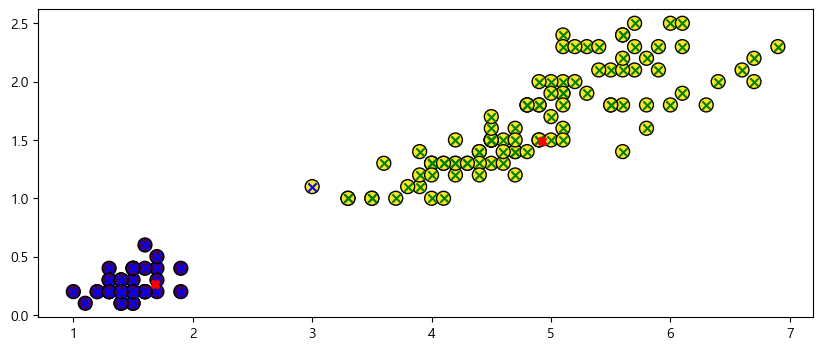

In [61]:
# 그래프로 시각화
import matplotlib.pyplot as plt
model = KMeans(n_clusters=2, n_init=10)
labels = model.fit(data).labels_

# 중심점 확인
c0, c1 = model.cluster_centers_

# 시각화를 위한 넘파이 배열 변환
data = np.array(data)

# 원본 및 예측, 중심점 시각화
plt.scatter(data[:,0], data[:,1], c=specie_labels, s=100, edgecolors='k')
plt.scatter(data[labels==0, 0], data[labels==0, 1], marker='x', c='g')
plt.scatter(data[labels==1, 0], data[labels==1, 1], marker='x', c='b')
plt.scatter(c0, c1, c='r', marker='X')
plt.show()

### 클러스터 3

In [65]:
iris = load_dataset('iris')
specie_labels = iris['species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2}).to_numpy()

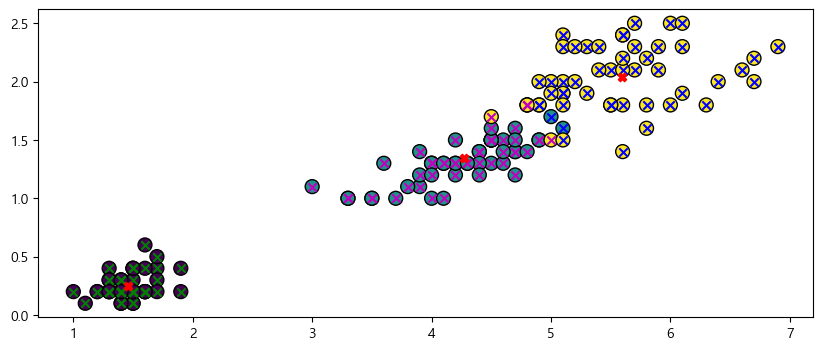

In [66]:
# 그래프로 시각화
import matplotlib.pyplot as plt
model = KMeans(n_clusters=3, n_init=10)
labels = model.fit(data).labels_

# 중심점 확인
centers = model.cluster_centers_

# 시각화를 위한 넘파이 배열 변환
data = np.array(data)

# 원본 및 예측, 중심점 시각화
plt.scatter(data[:,0], data[:,1], c=specie_labels, s=100, edgecolors='k')
plt.scatter(data[labels==0, 0], data[labels==0, 1], marker='x', c='g')
plt.scatter(data[labels==1, 0], data[labels==1, 1], marker='x', c='b')
plt.scatter(data[labels==2, 0], data[labels==2, 1], marker='x', c='m')
plt.scatter(centers[:,0], centers[:,1], c='r', marker='X')
plt.show()